In [65]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [66]:
data=pd.read_csv('/kaggle/input/youtube-videos-dataset/youtube.csv')

In [67]:
data.head()

,link,title,description,category
0,JLZlCZ0,Ep 1| Travelling through North East India | Of...,Tanya Khanijow\n671K subscribers\nSUBSCRIBE\nT...,travel
1,i9E_Blai8vk,Welcome to Bali | Travel Vlog | Priscilla Lee,Priscilla Lee\n45.6K subscribers\nSUBSCRIBE\n*...,travel
2,r284c-q8oY,My Solo Trip to ALASKA | Cruising From Vancouv...,Allison Anderson\n588K subscribers\nSUBSCRIBE\...,travel
3,Qmi-Xwq-ME,Traveling to the Happiest Country in the World!!,Yes Theory\n6.65M subscribers\nSUBSCRIBE\n*BLA...,travel
4,_lcOX55Ef70,Solo in Paro Bhutan | Tiger's Nest visit | Bhu...,Tanya Khanijow\n671K subscribers\nSUBSCRIBE\nH...,travel


In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3599 entries, 0 to 3598
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   link         3599 non-null   object
 1   title        3599 non-null   object
 2   description  3599 non-null   object
 3   category     3599 non-null   object
dtypes: object(4)
memory usage: 112.6+ KB


In [69]:
data.isnull().sum()

link           0
title          0
description    0
category       0
dtype: int64

In [70]:
data['category'].unique()

array(['travel', 'food', 'art_music', 'history'], dtype=object)

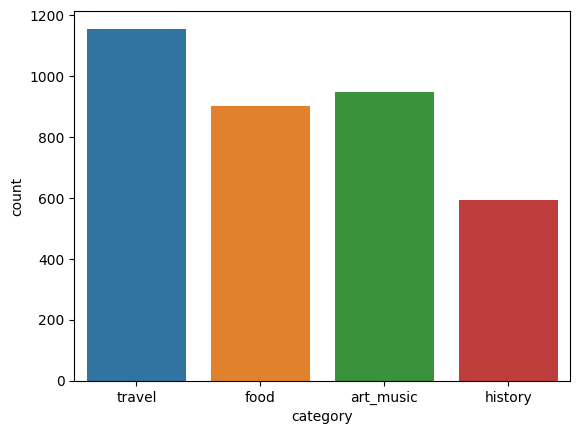

In [71]:
sns.countplot(x = data['category'])
plt.show()

# Pre Processing 

## Remove Punctuation 

In [72]:
import string

In [73]:
punct=string.punctuation

In [74]:
punct

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [75]:
def remove_punct(text):
    text_nonpunct=''.join([char for char in text if char not in punct])
    return text_nonpunct

In [76]:
data['text_nonpunct']=data['description'].apply(lambda x:remove_punct(x.lower()))

In [77]:
data.head()

,link,title,description,category,text_nonpunct
0,JLZlCZ0,Ep 1| Travelling through North East India | Of...,Tanya Khanijow\n671K subscribers\nSUBSCRIBE\nT...,travel,tanya khanijow\n671k subscribers\nsubscribe\nt...
1,i9E_Blai8vk,Welcome to Bali | Travel Vlog | Priscilla Lee,Priscilla Lee\n45.6K subscribers\nSUBSCRIBE\n*...,travel,priscilla lee\n456k subscribers\nsubscribe\ndi...
2,r284c-q8oY,My Solo Trip to ALASKA | Cruising From Vancouv...,Allison Anderson\n588K subscribers\nSUBSCRIBE\...,travel,allison anderson\n588k subscribers\nsubscribe\...
3,Qmi-Xwq-ME,Traveling to the Happiest Country in the World!!,Yes Theory\n6.65M subscribers\nSUBSCRIBE\n*BLA...,travel,yes theory\n665m subscribers\nsubscribe\nblack...
4,_lcOX55Ef70,Solo in Paro Bhutan | Tiger's Nest visit | Bhu...,Tanya Khanijow\n671K subscribers\nSUBSCRIBE\nH...,travel,tanya khanijow\n671k subscribers\nsubscribe\nh...


## Remove Stopwords

In [78]:
from nltk.corpus import stopwords
StopWords=stopwords.words('english')

In [79]:
StopWords[:5]

['a', 'about', 'above', 'after', 'again']

In [80]:
def remove_stopwords(text):
    filtered_text = ' '.join(word for word in text.split() if word.lower() not in StopWords)
    return filtered_text

data['text_nonStopwords']=data['text_nonpunct'].apply(lambda x : remove_stopwords(x))

## Tokenization 

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
tokenizer = Tokenizer(
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(data['text_nonStopwords'])

In [83]:
data['text_sequences'] = tokenizer.texts_to_sequences(data['text_nonStopwords'])

In [84]:
for word, index in tokenizer.word_index.items():
    print(word, index)
    if index == 10:
        break

subscribe 1
show 2
subscribers 3
songs 4
video 5
food 6
hindi 7
music 8
travel 9
song 10


In [85]:
vocab_size = len(tokenizer.word_index)

In [86]:
data.head()

,link,title,description,category,text_nonpunct,text_nonStopwords,text_sequences
0,JLZlCZ0,Ep 1| Travelling through North East India | Of...,Tanya Khanijow\n671K subscribers\nSUBSCRIBE\nT...,travel,tanya khanijow\n671k subscribers\nsubscribe\nt...,tanya khanijow 671k subscribers subscribe jour...,"[1498, 1600, 1413, 3, 1, 268, 4457, 251, 248, ..."
1,i9E_Blai8vk,Welcome to Bali | Travel Vlog | Priscilla Lee,Priscilla Lee\n45.6K subscribers\nSUBSCRIBE\n*...,travel,priscilla lee\n456k subscribers\nsubscribe\ndi...,priscilla lee 456k subscribers subscribe discl...,"[7372, 319, 2163, 3, 1, 864, 27, 1414, 2904, 6..."
2,r284c-q8oY,My Solo Trip to ALASKA | Cruising From Vancouv...,Allison Anderson\n588K subscribers\nSUBSCRIBE\...,travel,allison anderson\n588k subscribers\nsubscribe\...,allison anderson 588k subscribers subscribe sp...,"[5550, 2622, 5551, 3, 1, 577, 669, 221, 7374, ..."
3,Qmi-Xwq-ME,Traveling to the Happiest Country in the World!!,Yes Theory\n6.65M subscribers\nSUBSCRIBE\n*BLA...,travel,yes theory\n665m subscribers\nsubscribe\nblack...,yes theory 665m subscribers subscribe black fr...,"[907, 1976, 2906, 3, 1, 498, 1842, 1499, 5552,..."
4,_lcOX55Ef70,Solo in Paro Bhutan | Tiger's Nest visit | Bhu...,Tanya Khanijow\n671K subscribers\nSUBSCRIBE\nH...,travel,tanya khanijow\n671k subscribers\nsubscribe\nh...,tanya khanijow 671k subscribers subscribe here...,"[1498, 1600, 1413, 3, 1, 2907, 616, 40, 116, 4..."


In [87]:
from collections import Counter

# Compute sequence lengths
sequence_lengths = [len(seq) for seq in data['text_sequences']]

# Count frequencies of each length
length_counts = Counter(sequence_lengths)

# Prepare data for plotting
lengths = list(length_counts.keys())
counts = list(length_counts.values())

In [ ]:
length_counts.most_common(5)

[(21, 131), (20, 110), (14, 97), (18, 89), (5, 89)]

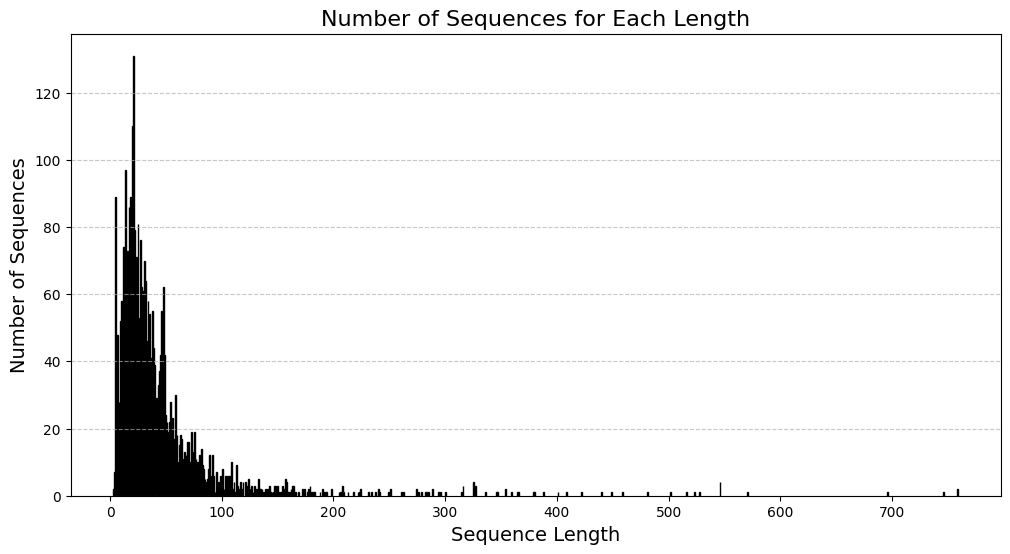

In [89]:
# Plot the data
plt.figure(figsize=(12, 6))
plt.bar(lengths, counts, color='skyblue', edgecolor='black')
plt.title('Number of Sequences for Each Length', fontsize=16)
plt.xlabel('Sequence Length', fontsize=14)
plt.ylabel('Number of Sequences', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
input_shape = 70 

## Padding

In [ ]:
# Sequence Padding
from tensorflow import  keras
from keras.preprocessing.sequence import pad_sequences
X=pad_sequences(data['text_sequences'],
    maxlen=input_shape,     
    padding='post',     
    truncating='post',   
)

## Labeling Target

In [92]:
y=data['category']

In [93]:
from sklearn.preprocessing import LabelEncoder
LB=LabelEncoder()
y=LB.fit_transform(y)

## Splitting

In [94]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
                                                    random_state=100) # encoded_matrix
print("X_train : \n",X_train)
print("X_test  : \n",X_test)


X_train : 
 [[ 4112   429  4113 ...     0     0     0]
 [ 1164  5733     1 ...     0     0     0]
 [17276   182 17277 ...     0     0     0]
 ...
 [ 2829    31   574 ...   574   956    29]
 [   72     8   805 ...     2   340     0]
 [    6 16887  9234 ...     0     0     0]]
X_test  : 
 [[ 3310  1421  3828 ...     0     0     0]
 [    9   445   446 ...     0     0     0]
 [  410  1111  1060 ...     0     0     0]
 ...
 [    7  1896   102 ...     0     0     0]
 [10063 19896     3 ...     0     0     0]
 [   14   355   160 ...     0     0     0]]


In [95]:
print("X_train shape : ",X_train.shape)
print("X_test  shape : ",X_test.shape)

X_train shape :  (2879, 70)
X_test  shape :  (720, 70)


# RNN Model

In [ ]:

# Define the model
model = tf.keras.models.Sequential([
    # Embedding layer
    tf.keras.layers.Embedding(vocab_size+1, 32, input_shape=[input_shape]),  # Embedding layer
    
    # RNN layer
    tf.keras.layers.SimpleRNN(32, return_sequences=True),  # RNN layer
    
    # Batch Normalization after RNN
    tf.keras.layers.BatchNormalization(),  # Batch Normalization

    # RNN layer
    tf.keras.layers.SimpleRNN(32, return_sequences=False),  # RNN layer
    
    # Batch Normalization after RNN
    tf.keras.layers.BatchNormalization(),  # Batch Normalization

    # Dropout layer for regularization
    tf.keras.layers.Dropout(0.25),  # Dropout layer
    
    # Dense output layer with softmax activation for multi-class classification
    tf.keras.layers.Dense(4, activation="softmax")  # Output layer
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [97]:
print(model.summary())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 70, 32)         │       817,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 70, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 70, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 821,860 (3.14 MB)

 Trainable params: 821,732 (3.13 MB)

 Non-trainable params: 128 (512.00 B)

None


In [98]:
# Compiling the model
model.compile(loss='sparse_categorical_crossentropy', optimizer="adam", metrics=["accuracy"])

# Training and evaluating the model
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2)

Epoch 1/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.3212 - loss: 1.6356 - val_accuracy: 0.4566 - val_loss: 1.1475
Epoch 2/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5660 - loss: 0.9483 - val_accuracy: 0.5156 - val_loss: 1.1134
Epoch 3/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7694 - loss: 0.5807 - val_accuracy: 0.6649 - val_loss: 0.8461
Epoch 4/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9523 - loss: 0.1908 - val_accuracy: 0.6806 - val_loss: 0.8035
Epoch 5/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9854 - loss: 0.0784 - val_accuracy: 0.6823 - val_loss: 0.9128
Epoch 6/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9955 - loss: 0.0379 - val_accuracy: 0.7118 - val_loss: 0.9366
Epoch 7/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9957 - loss: 0.0271 - val_accuracy: 0.6875 - val_loss: 1.0129
Epoch 8/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9964 - loss: 0.0237 - val_accuracy: 0.7049 - v

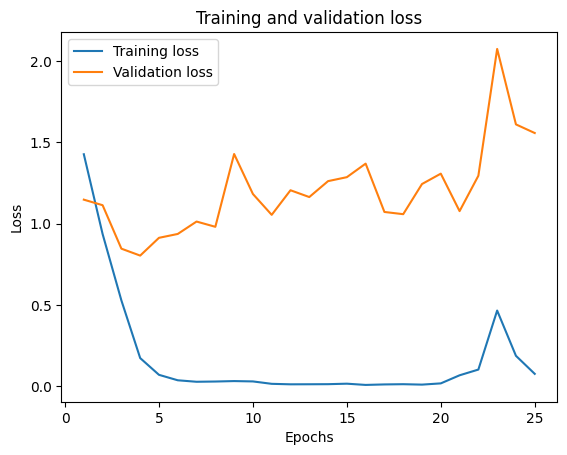

In [99]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

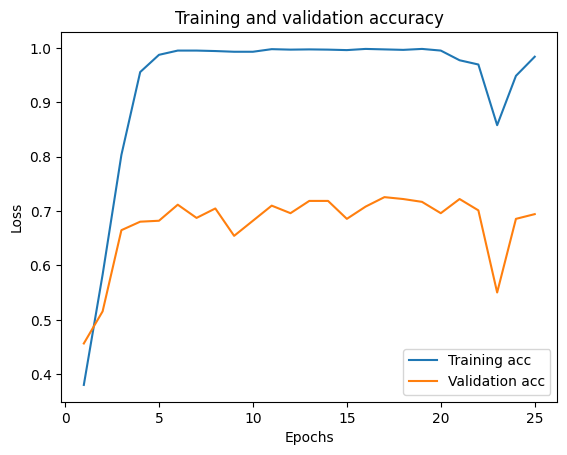

In [100]:

plt.clf()   # clear figure
acc_values = history.history['accuracy']
val_acc_values = history.history['val_accuracy']

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [101]:
# Confusion Matrix
y_pred = (model.predict(X_test).argmax(axis=-1)).tolist()

class_names = LB.classes_

# Compute classification report
from sklearn.metrics import classification_report, confusion_matrix
print("Classification report : \n",classification_report(y_test, y_pred, target_names = class_names))


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
Classification report : 
               precision    recall  f1-score   support

   art_music       0.95      0.84      0.89       193
        food       0.56      0.59      0.57       170
     history       0.42      0.47      0.45       110
      travel       0.67      0.67      0.67       247

    accuracy                           0.67       720
   macro avg       0.65      0.64      0.64       720
weighted avg       0.68      0.67      0.67       720



Confusion matrix : 



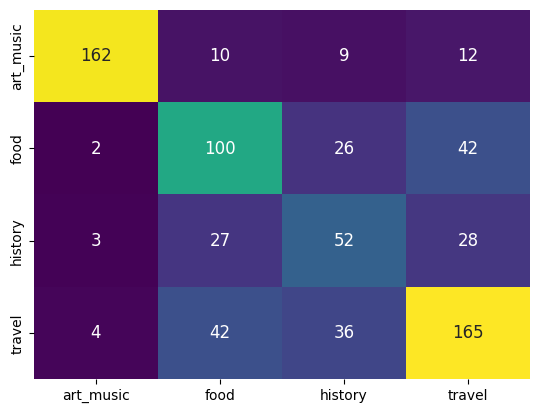

Normalized confusion matrix : 



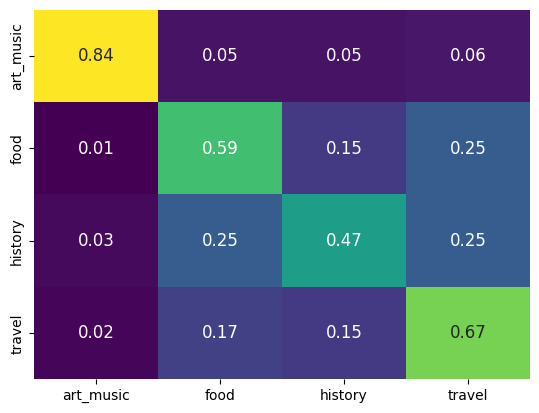

In [102]:
# Function to draw confusion matrix
def draw_confusion_matrix(true, preds, normalize=None):
  # Compute confusion matrix
  conf_matx = confusion_matrix(true, preds, normalize = normalize)
  conf_matx = np.round(conf_matx, 2)
  # print(conf_matx)

  # plt.subplots(figsize=(14,8))
  sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis",xticklabels=class_names,yticklabels=class_names)
  plt.show()

print("Confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred)

print("Normalized confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred,"true")

# LSTM Model

In [ ]:

# Define the model
model = tf.keras.models.Sequential([
    # Embedding layer
    tf.keras.layers.Embedding(vocab_size+1, 32, input_shape=[input_shape]),  # Embedding layer
    
    # LSTM layer
    tf.keras.layers.LSTM(32, return_sequences=True),  # LSTM layer
    
    # Batch Normalization after RNN
    tf.keras.layers.BatchNormalization(),  # Batch Normalization

    # LSTM layer
    tf.keras.layers.LSTM(32, return_sequences=False),  # LSTM layer
    
    # Batch Normalization after LSTM
    tf.keras.layers.BatchNormalization(),  # Batch Normalization

    # Dropout layer for regularization
    tf.keras.layers.Dropout(0.25),  # Dropout layer
    
    # Dense output layer with softmax activation for multi-class classification
    tf.keras.layers.Dense(4, activation="softmax")  # Output layer
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [104]:
# Compiling the model
model.compile(loss='sparse_categorical_crossentropy', optimizer="adam", metrics=["accuracy"])

# Training and evaluating the model
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2)

Epoch 1/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.2905 - loss: 1.5929 - val_accuracy: 0.3160 - val_loss: 1.3623
Epoch 2/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4124 - loss: 1.2135 - val_accuracy: 0.3993 - val_loss: 1.2939
Epoch 3/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5946 - loss: 0.8600 - val_accuracy: 0.4566 - val_loss: 1.1500
Epoch 4/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7662 - loss: 0.5346 - val_accuracy: 0.5938 - val_loss: 1.0301
Epoch 5/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8775 - loss: 0.3558 - val_accuracy: 0.5434 - val_loss: 1.8177
Epoch 6/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8824 - loss: 0.3576 - val_accuracy: 0.4757 - val_loss: 2.1064
Epoch 7/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9136 - loss: 0.2540 - val_accuracy: 0.8542 - val_loss: 0.5447
Epoch 8/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9441 - loss: 0.1786 - val_accuracy: 0.8767 - v

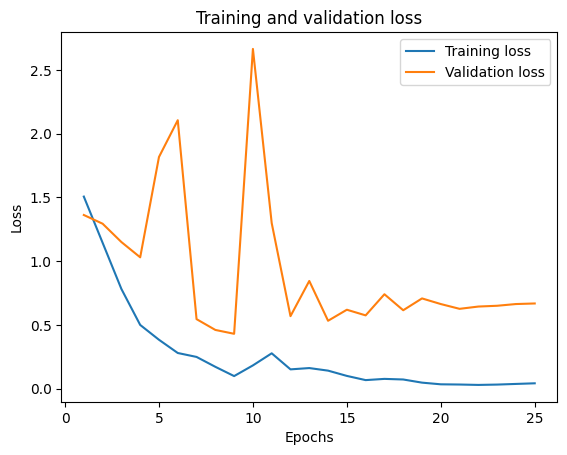

In [105]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

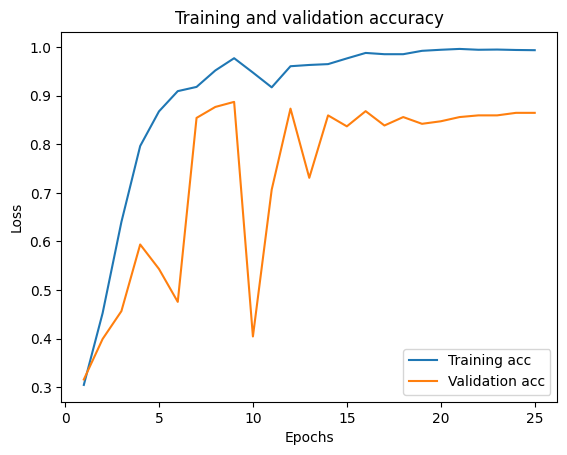

In [106]:

plt.clf()   # clear figure
acc_values = history.history['accuracy']
val_acc_values = history.history['val_accuracy']

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [107]:
# Confusion Matrix
y_pred = (model.predict(X_test).argmax(axis=-1)).tolist()

class_names = LB.classes_

# Compute classification report
from sklearn.metrics import classification_report, confusion_matrix
print("Classification report : \n",classification_report(y_test, y_pred, target_names = class_names))


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Classification report : 
               precision    recall  f1-score   support

   art_music       0.95      0.88      0.91       193
        food       0.81      0.81      0.81       170
     history       0.79      0.89      0.84       110
      travel       0.84      0.85      0.84       247

    accuracy                           0.85       720
   macro avg       0.85      0.85      0.85       720
weighted avg       0.85      0.85      0.85       720



Confusion matrix : 



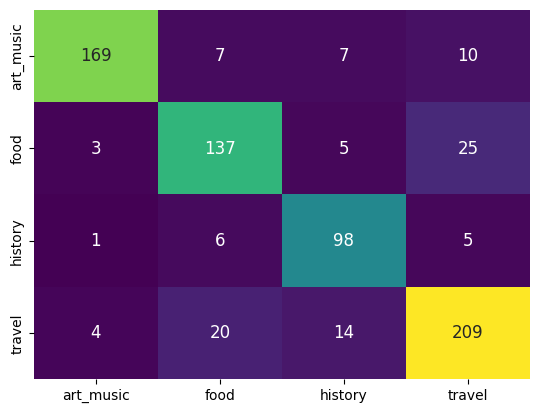

Normalized confusion matrix : 



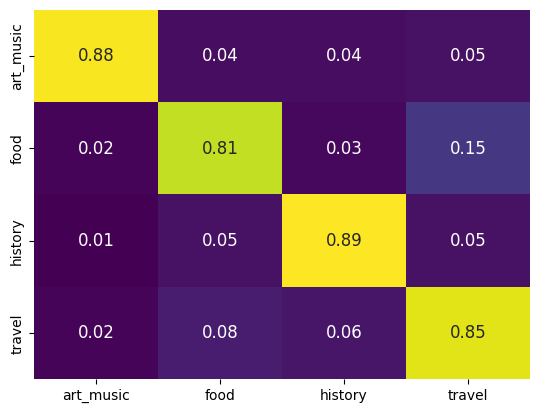

In [108]:
# Function to draw confusion matrix
def draw_confusion_matrix(true, preds, normalize=None):
  # Compute confusion matrix
  conf_matx = confusion_matrix(true, preds, normalize = normalize)
  conf_matx = np.round(conf_matx, 2)
  # print(conf_matx)

  # plt.subplots(figsize=(14,8))
  sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis",xticklabels=class_names,yticklabels=class_names)
  plt.show()

print("Confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred)

print("Normalized confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred,"true")

# GRU Model

In [ ]:

# Define the model
model = tf.keras.models.Sequential([
    # Embedding layer
    tf.keras.layers.Embedding(vocab_size+1, 32, input_shape=[input_shape]),  # Embedding layer
    
    # GRU layer
    tf.keras.layers.GRU(32, return_sequences=True),  # RNN layer
    
    # Batch Normalization after GRU
    tf.keras.layers.BatchNormalization(),  # Batch Normalization

    # GRU layer
    tf.keras.layers.GRU(32, return_sequences=False),  # RNN layer
    
    # Batch Normalization after GRU
    tf.keras.layers.BatchNormalization(),  # Batch Normalization

    # Dropout layer for regularization
    tf.keras.layers.Dropout(0.25),  # Dropout layer
    
    # Dense output layer with softmax activation for multi-class classification
    tf.keras.layers.Dense(4, activation="softmax")  # Output layer
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [110]:
# Compiling the model
model.compile(loss='sparse_categorical_crossentropy', optimizer="adam", metrics=["accuracy"])

# Training and evaluating the model
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2)

Epoch 1/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.2718 - loss: 1.5744 - val_accuracy: 0.3247 - val_loss: 1.3741
Epoch 2/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3353 - loss: 1.3582 - val_accuracy: 0.3455 - val_loss: 1.3736
Epoch 3/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3877 - loss: 1.2267 - val_accuracy: 0.3385 - val_loss: 1.3625
Epoch 4/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4448 - loss: 1.1473 - val_accuracy: 0.1580 - val_loss: 1.5461
Epoch 5/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4332 - loss: 1.1536 - val_accuracy: 0.3368 - val_loss: 1.6685
Epoch 6/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4601 - loss: 1.0937 - val_accuracy: 0.1458 - val_loss: 5.7241
Epoch 7/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6843 - loss: 0.7323 - val_accuracy: 0.4427 - val_loss: 2.7170
Epoch 8/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9451 - loss: 0.2000 - val_accuracy: 0.3333 - v

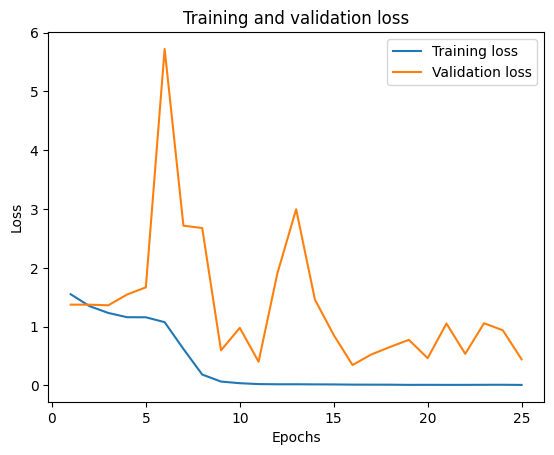

In [111]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

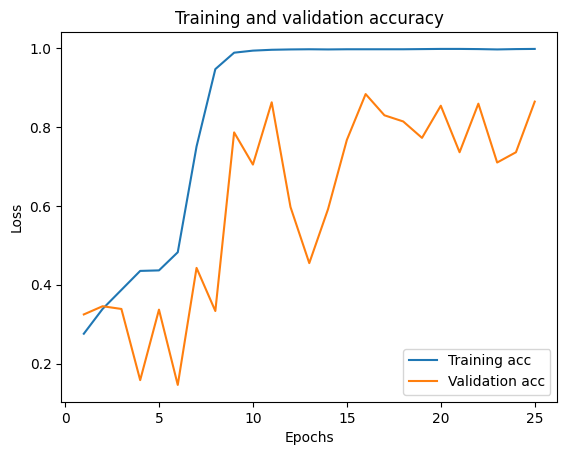

In [112]:

plt.clf()   # clear figure
acc_values = history.history['accuracy']
val_acc_values = history.history['val_accuracy']

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [113]:
# Confusion Matrix
y_pred = (model.predict(X_test).argmax(axis=-1)).tolist()

class_names = LB.classes_

# Compute classification report
from sklearn.metrics import classification_report, confusion_matrix
print("Classification report : \n",classification_report(y_test, y_pred, target_names = class_names))


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Classification report : 
               precision    recall  f1-score   support

   art_music       0.93      0.89      0.91       193
        food       0.68      0.94      0.79       170
     history       0.99      0.76      0.86       110
      travel       0.91      0.79      0.84       247

    accuracy                           0.85       720
   macro avg       0.88      0.85      0.85       720
weighted avg       0.87      0.85      0.85       720



Confusion matrix : 



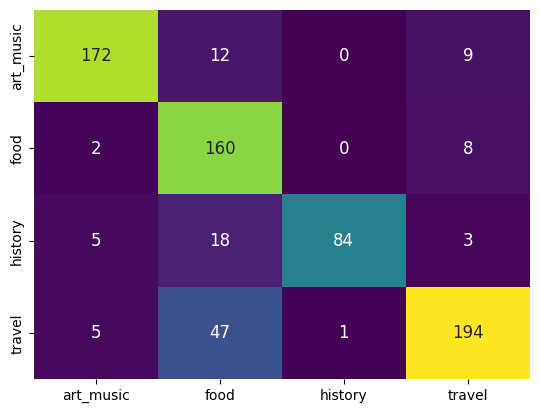

Normalized confusion matrix : 



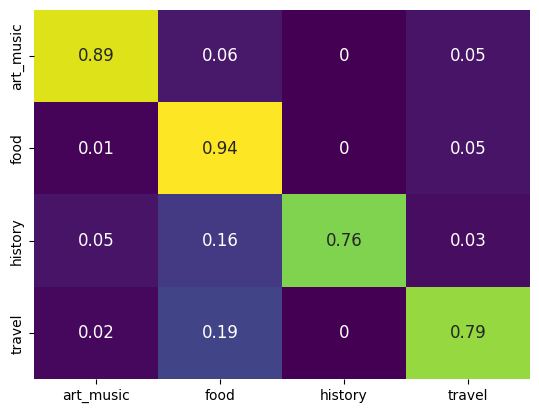

In [114]:
# Function to draw confusion matrix
def draw_confusion_matrix(true, preds, normalize=None):
  # Compute confusion matrix
  conf_matx = confusion_matrix(true, preds, normalize = normalize)
  conf_matx = np.round(conf_matx, 2)
  # print(conf_matx)

  # plt.subplots(figsize=(14,8))
  sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis",xticklabels=class_names,yticklabels=class_names)
  plt.show()

print("Confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred)

print("Normalized confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred,"true")

# BILSTM Model

In [ ]:
# Define the model (converted to BiLSTM)
model = tf.keras.models.Sequential([
    # Embedding layer
    tf.keras.layers.Embedding(vocab_size+1, 32, input_shape=[input_shape]),  # Embedding layer

    # BiLSTM layer (returns full sequence for stacking)
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(32, return_sequences=True)
    ),  # BiLSTM layer

    # Batch Normalization after first BiLSTM
    tf.keras.layers.BatchNormalization(),  # Batch Normalization

    # BiLSTM layer (returns final state only)
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(32, return_sequences=False)
    ),  # BiLSTM layer

    # Batch Normalization after second BiLSTM
    tf.keras.layers.BatchNormalization(),  # Batch Normalization

    # Dropout layer for regularization
    tf.keras.layers.Dropout(0.25),  # Dropout layer

    # Dense output layer with softmax activation for multi-class classification
    tf.keras.layers.Dense(4, activation="softmax")  # Output layer
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [116]:
# Compiling the model
model.compile(loss='sparse_categorical_crossentropy', optimizer="adam", metrics=["accuracy"])

# Training and evaluating the model
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2)

Epoch 1/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.5061 - loss: 1.2711 - val_accuracy: 0.5087 - val_loss: 1.3308
Epoch 2/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9383 - loss: 0.2070 - val_accuracy: 0.6111 - val_loss: 1.2764
Epoch 3/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9840 - loss: 0.0702 - val_accuracy: 0.7847 - val_loss: 1.1329
Epoch 4/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9885 - loss: 0.0466 - val_accuracy: 0.8663 - val_loss: 0.9043
Epoch 5/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9931 - loss: 0.0309 - val_accuracy: 0.8854 - val_loss: 0.6443
Epoch 6/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9959 - loss: 0.0212 - val_accuracy: 0.8490 - val_loss: 0.4852
Epoch 7/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9965 - loss: 0.0199 - val_accuracy: 0.7986 - val_loss: 0.5751
Epoch 8/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9986 - loss: 0.0122 - val_accuracy: 0.8733 - v

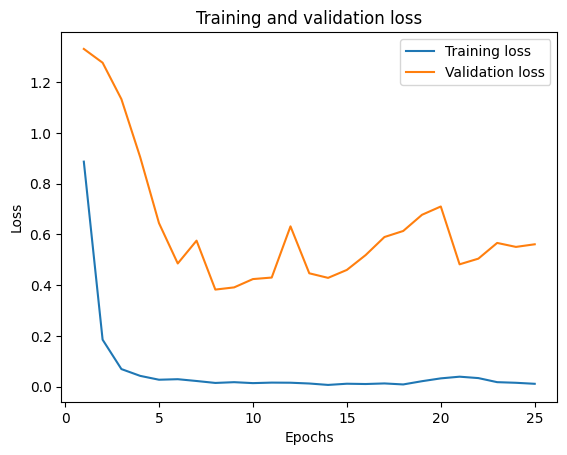

In [117]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

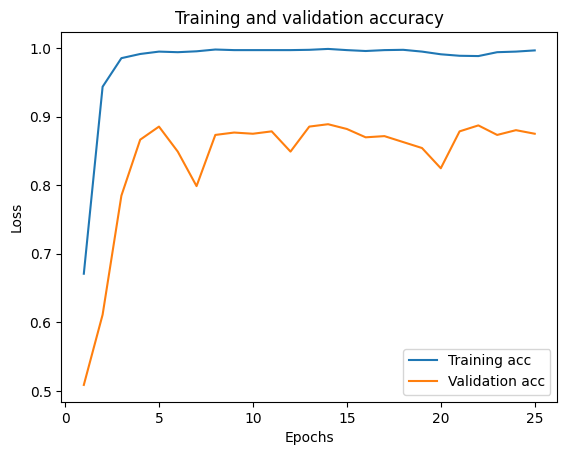

In [118]:

plt.clf()   # clear figure
acc_values = history.history['accuracy']
val_acc_values = history.history['val_accuracy']

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [119]:
# Confusion Matrix
y_pred = (model.predict(X_test).argmax(axis=-1)).tolist()

class_names = LB.classes_

# Compute classification report
from sklearn.metrics import classification_report, confusion_matrix
print("Classification report : \n",classification_report(y_test, y_pred, target_names = class_names))


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Classification report : 
               precision    recall  f1-score   support

   art_music       0.94      0.91      0.92       193
        food       0.76      0.89      0.82       170
     history       0.78      0.93      0.85       110
      travel       0.92      0.76      0.83       247

    accuracy                           0.86       720
   macro avg       0.85      0.87      0.86       720
weighted avg       0.87      0.86      0.86       720



Confusion matrix : 



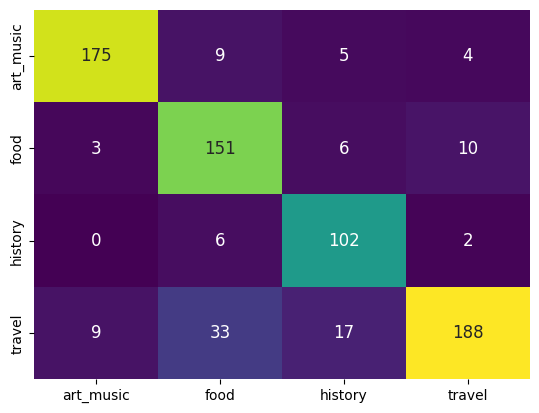

Normalized confusion matrix : 



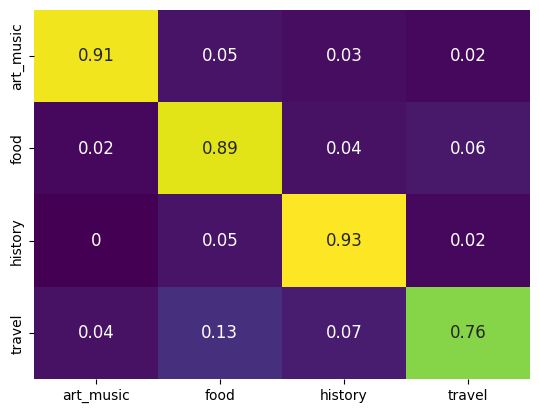

In [120]:
# Function to draw confusion matrix
def draw_confusion_matrix(true, preds, normalize=None):
  # Compute confusion matrix
  conf_matx = confusion_matrix(true, preds, normalize = normalize)
  conf_matx = np.round(conf_matx, 2)
  # print(conf_matx)

  # plt.subplots(figsize=(14,8))
  sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis",xticklabels=class_names,yticklabels=class_names)
  plt.show()

print("Confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred)

print("Normalized confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred,"true")

In [ ]:
# BiLSTM layer (returns final state only)
tf.keras.layers.SimpleRNN(32, return_sequences=False)
tf.keras.layers.LSTM(32, return_sequences=False)
tf.keras.layers.GRU(32, return_sequences=False)

tf.keras.layers.Bidirectional(
tf.keras.layers.LSTM(32, return_sequences=False)
)
